# SIMULADO INTERMEDIÁRIO

In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from graph_tool.all import *

In [2]:
sns.set()

Carregue a rede.

In [ ]:
# escreva seu código aqui
g = load_graph("simulado.gt")

Visualize a rede.

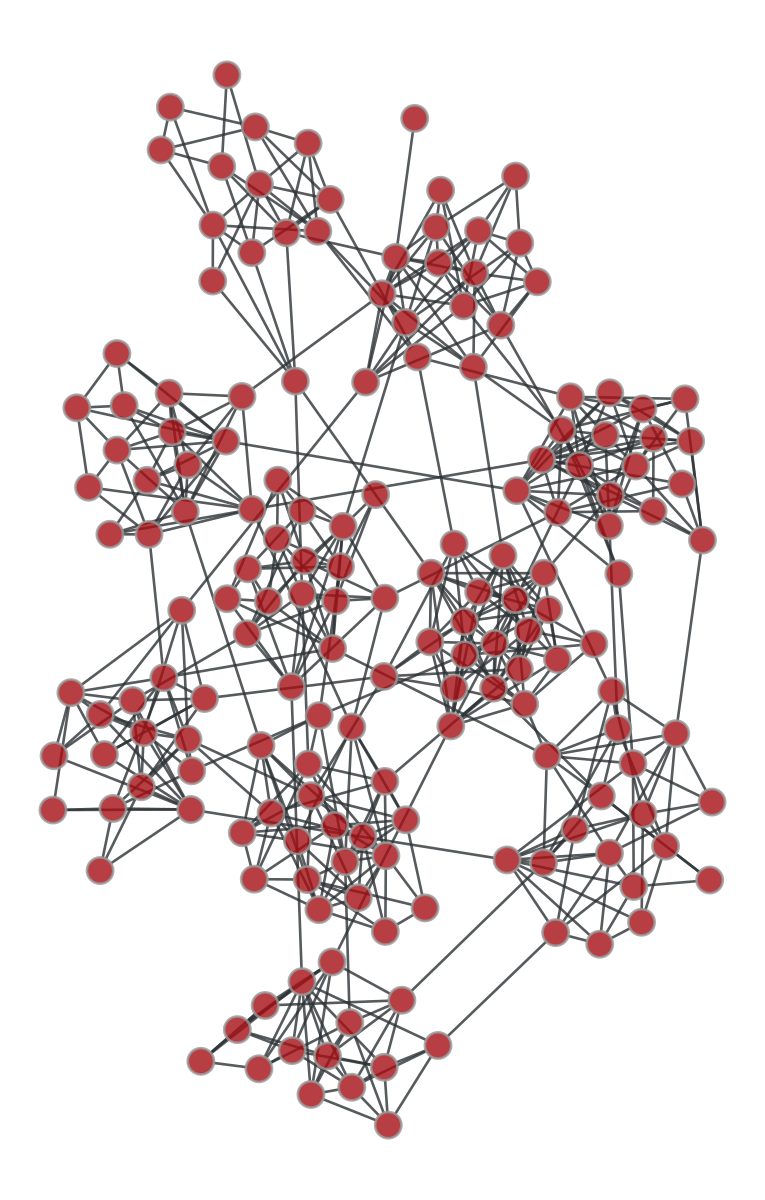

In [5]:
# escreva seu código aqui
graph_draw(g);

Obtenha a percepção de eficácia pessoal dos colaboradores.

In [6]:
# escreva seu código aqui
eficacia = g.vp['eficacia']

Construa um dataframe em que as colunas correspondem à Variável A, à Variável B e a essa percepção de eficácia.

In [8]:
# escreva seu código aqui
df = pd.DataFrame({
    'grau': [v.out_degree() for v in g.vertices()],
    'agrupamento': local_clustering(g),
    'eficacia': eficacia
})

df.head()

,grau,agrupamento,eficacia
0,6,0.266667,3.0
1,11,0.254545,10.0
2,5,0.200000,2.0
3,5,0.200000,2.0
4,7,0.333333,3.0


Implemente uma regressão linear em que a dependente é eficácia pessoal e as independentes são a **Variável A** e a **Variável B**.

In [10]:
# escreva seu código aqui
dep = df['eficacia']
ind = df[['grau', 'agrupamento']]
ind = sm.add_constant(ind)

model = sm.OLS(dep, ind)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               eficacia   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     81.55
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.95e-25
Time:                        18:35:05   Log-Likelihood:                -253.84
No. Observations:                 170   AIC:                             513.7
Df Residuals:                     167   BIC:                             523.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2291      0.388     -0.590      0.556      -0.996       0.537
grau            0.4950      0.040     12.337      0.000       0.416       0.574
agrupamento    -0.5577      0.632     -0.883      0.379      -1.805       0.690
==============================================================================
Omnibus:                      232.986   Durbin-Watson:                   1.970
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            33487.135
Skew:                          -5.247   Prob(JB):                         0.00
Kurtosis:                      70.952   Cond. No.                         60.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Plote os três gráficos de resíduos dessa regressão.

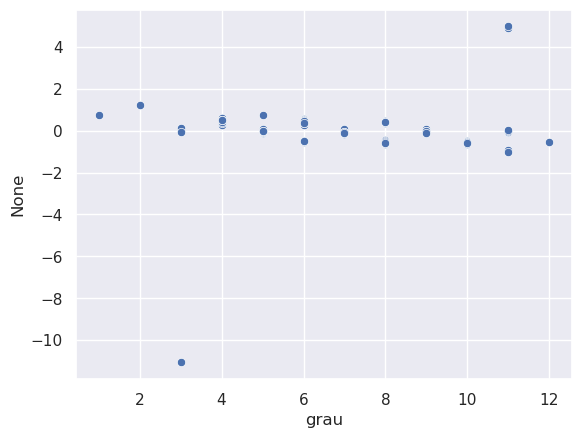

In [12]:
# escreva seu código aqui
sns.scatterplot(x=df['grau'], y=result.resid);

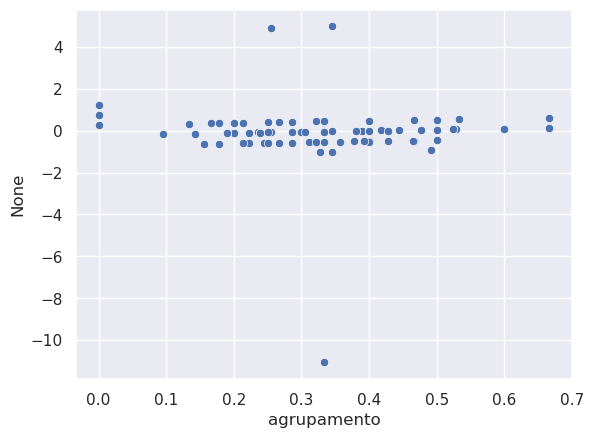

In [13]:
# escreva seu código aqui

sns.scatterplot(x=df['agrupamento'], y=result.resid);

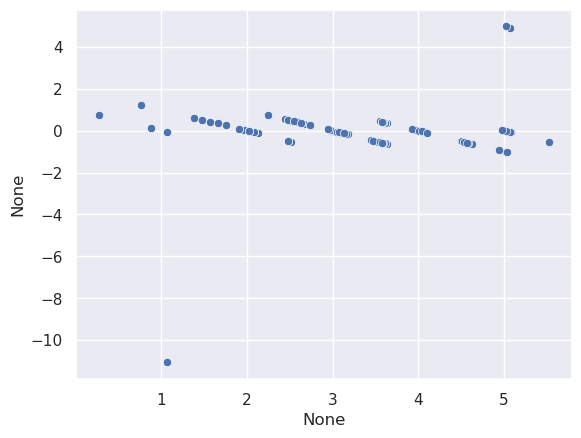

In [11]:
# escreva seu código aqui
sns.scatterplot(x=result.fittedvalues, y=result.resid);

Implemente a modificação.

In [14]:
# escreva seu código aqui
df['eficacia'].value_counts()

eficacia
 3.0     77
 2.0     42
 4.0     37
 1.0      6
 5.0      5
 10.0     2
-10.0     1
Name: count, dtype: int64

In [15]:
df = df[(df['eficacia'] >= 1) & (df['eficacia'] <= 5)]

In [16]:
# escreva seu código aqui
dep = df['eficacia']

ind = df[['grau', 'agrupamento']]
ind = sm.add_constant(ind)

model = sm.OLS(dep, ind)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               eficacia   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     563.2
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.44e-74
Time:                        18:42:51   Log-Likelihood:                -38.978
No. Observations:                 167   AIC:                             83.96
Df Residuals:                     164   BIC:                             93.31
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6834      0.112      6.088      0.000       0.462       0.905
grau            0.3743      0.012     31.791      0.000       0.351       0.398
agrupamento    -0.8049      0.180     -4.483      0.000      -1.159      -0.450
==============================================================================
Omnibus:                       22.438   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                6.501
Skew:                           0.072   Prob(JB):                       0.0388
Kurtosis:                       2.044   Cond. No.                         59.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Plote os novos resíduos.

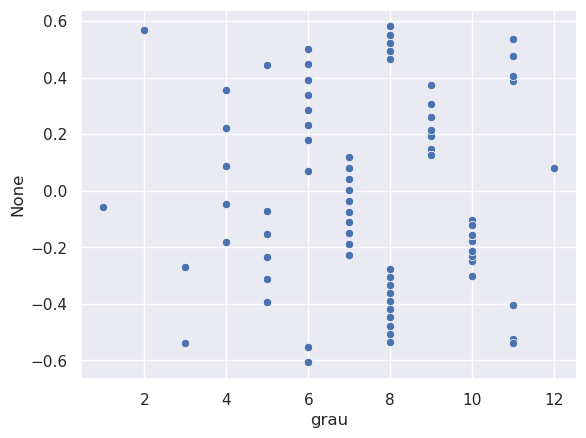

In [18]:
# escreva seu código aqui
sns.scatterplot(x=df['grau'], y=result.resid);

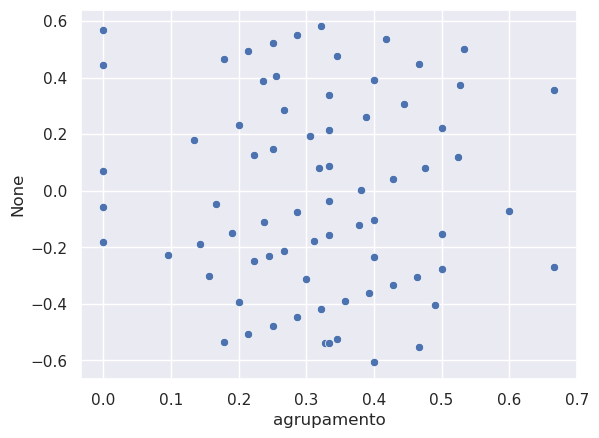

In [19]:
# escreva seu código aqui
sns.scatterplot(x=df['agrupamento'], y=result.resid);

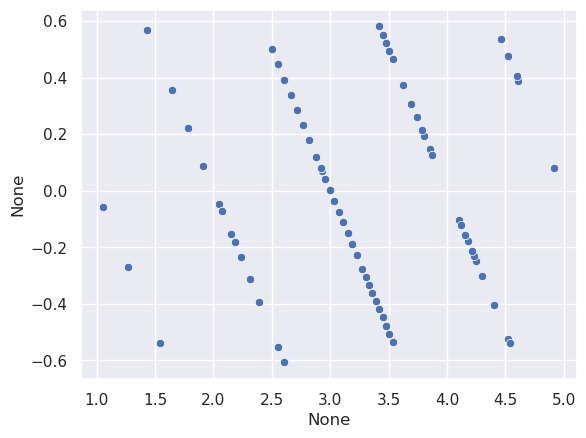

In [20]:
# escreva seu código aqui
sns.scatterplot(x=result.fittedvalues, y=result.resid);